# 04a — Conditional VAE Generator

**What this notebook does**: trains a Conditional Variational Autoencoder (CVAE)
to generate synthetic log-signatures of energy price paths.

**Input**: `data/logsigs.parquet`, `data/norm_stats.json` (from notebook 03)

**Outputs**:
- `data/cvae_model.pt` — trained CVAE weights
- `data/cvae_generated_logsigs.parquet` — 10,000 generated log-signatures

---

## Mathematical background

### VAE objective

A VAE learns a latent variable model $p_\theta(x) = \int p_\theta(x|z) p(z) dz$
by maximising the Evidence Lower Bound (ELBO):

$$\mathcal{L}(\theta, \phi) = \mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)]
- \text{KL}(q_\phi(z|x) \| p(z))$$

The first term is the **reconstruction loss** — how well the decoder
reconstructs $x$ from the latent code $z$.
The second term is the **KL regulariser** — it keeps the posterior
$q_\phi(z|x)$ close to the prior $p(z) = \mathcal{N}(0, I)$.

### Conditional extension

In a CVAE the encoder and decoder both receive a conditioning vector $c$:

$$\mathcal{L}(\theta, \phi) = \mathbb{E}_{q_\phi(z|x,c)}[\log p_\theta(x|z,c)]
- \text{KL}(q_\phi(z|x,c) \| p(z))$$

Our conditioning vector $c_t$ contains:
- Realised volatility of the current segment
- Mean wind percentage
- Fourier seasonality features (sin/cos of month and hour)
- Regime one-hot encoding (calm / volatile / spike)
- Log-signature of the **previous** segment (enables sequential generation)

### Why VAE over GAN for small data

GANs require sufficient data to reach a generator-discriminator equilibrium.
With ~700 segments (4 years × ~175 weeks) this is a small dataset by deep
learning standards. VAEs optimise a tractable lower bound and converge
reliably with far fewer samples — exactly the regime of Bühl er et al. (2020).

### Connection to the universal approximation theorem

The decoder $f_\theta : \mathbb{R}^{d_z} \times \mathbb{R}^{d_c} \to \mathbb{R}^{d_s}$
is a feedforward neural network. By the UAT (Hornik 1991), it can approximate
any continuous function on a compact set — including the mapping from
(latent code, market state) to log-signature. This is the same UAT argument
used in my dissertation to justify the neural network option pricer.


In [3]:
%pip install -q torch polars pyarrow matplotlib numpy scikit-learn

In [4]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
DATA_DIR = Path("/content/drive/MyDrive/energy_synthetic_data/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
print(f"Data directory: {DATA_DIR}")

Mounted at /content/drive
Data directory: /content/drive/MyDrive/energy_synthetic_data/data


In [5]:
import json
import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from tqdm import tqdm

# Device: use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

PyTorch version: 2.10.0+cu128
Device: cuda


In [6]:
# ── Load data ─────────────────────────────────────────────────────────────────
df = pl.read_parquet(DATA_DIR / "logsigs.parquet")
df = df.sort("start_time")

with open(DATA_DIR / "norm_stats.json") as f:
    norm_stats = json.load(f)

logsig_dim = norm_stats["logsig_dim"]
seg_length = norm_stats["seg_length"]

# Join total_wind_mw and net_imbalance_volume from master.parquet
df_master = pl.read_parquet(DATA_DIR / "master.parquet")

# Cast start_time to same precision before joining
df = df.with_columns(
    pl.col("start_time").cast(pl.Datetime("us", "UTC"))
)
df_master = df_master.with_columns(
    pl.col("start_time").cast(pl.Datetime("us", "UTC"))
)

df = df.join(
    df_master.select(["start_time", "total_wind_mw", "net_imbalance_volume"]),
    on="start_time",
    how="left"
)

print(f"Loaded {df.shape[0]:,} log-signature segments")
print(f"Log-signature dimension: {logsig_dim}")
print(f"After join: {df.shape}")
print(f"Wind NaN count:      {df['total_wind_mw'].is_null().sum()}")
print(f"Imbalance NaN count: {df['net_imbalance_volume'].is_null().sum()}")
print(f"Regime distribution:")
print(df["regime"].value_counts())

Loaded 6,570 log-signature segments
Log-signature dimension: 31
After join: (6570, 109)
Wind NaN count:      4
Imbalance NaN count: 0
Regime distribution:
shape: (4, 2)
┌──────────┬───────┐
│ regime   ┆ count │
│ ---      ┆ ---   │
│ str      ┆ u32   │
╞══════════╪═══════╡
│ negative ┆ 675   │
│ spike    ┆ 1846  │
│ calm     ┆ 2045  │
│ volatile ┆ 2004  │
└──────────┴───────┘


---
## 1. Feature preparation

We build two tensors:
- **X**: the log-signatures (what the CVAE learns to generate)
- **C**: the conditioning vector (what the CVAE conditions on)

The conditioning vector $c$ includes:
- Standardised realised volatility
- Standardised mean wind
- Fourier seasonality (sin/cos month, sin/cos hour)
- Regime one-hot (3 dims)
- Lagged log-signature (the log-signature of the previous segment)

The lagged log-signature is what enables **sequential generation**:
at inference time we can chain segments together by feeding each
generated log-signature back as the conditioning for the next.


In [7]:
# ── Extract and scale log-signature columns ──────────────────────────────────
ls_cols = [c for c in df.columns if c.startswith("ls_")]
X_raw   = df.select(ls_cols).to_numpy().astype(np.float32)
# Drop near-zero variance columns — structural constants in lead-lag signatures
# that carry no distributional information and waste decoder capacity
col_stds = X_raw.std(axis=0)
active_cols = col_stds > 0.0
ls_cols_active = [c for c, keep in zip(ls_cols, active_cols) if keep]
X_raw = X_raw[:, active_cols]
logsig_dim = X_raw.shape[1]

print(f"Dropped {(~active_cols).sum()} zero-variance columns: "
      f"{[c for c, keep in zip(ls_cols, active_cols) if not keep]}")
print(f"Active log-sig dims: {logsig_dim}")
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X_raw).astype(np.float32)

# PCA on log-signatures for use in lagged conditioning
# Compressing 90-dim lagged logsig to 30 PCs reduces conditioning dimensionality
# while retaining >95% of variance — critical for generalisation with ~700 samples
N_LAGGED_PCS = min(30, logsig_dim - 1)
pca_lagged   = PCA(n_components=N_LAGGED_PCS)
X_pca        = pca_lagged.fit_transform(X_scaled).astype(np.float32)
print(f"Lagged PCA ({N_LAGGED_PCS} components): "
      f"{pca_lagged.explained_variance_ratio_.sum()*100:.1f}% variance")

print(f"X (log-signatures): {X_scaled.shape}")
print(f"X mean: {X_scaled.mean():.4f}, std: {X_scaled.std():.4f}")

Dropped 59 zero-variance columns: ['ls_0', 'ls_3', 'ls_6', 'ls_8', 'ls_9', 'ls_12', 'ls_15', 'ls_18', 'ls_19', 'ls_20', 'ls_21', 'ls_23', 'ls_25', 'ls_26', 'ls_27', 'ls_28', 'ls_29', 'ls_32', 'ls_35', 'ls_38', 'ls_39', 'ls_40', 'ls_41', 'ls_43', 'ls_46', 'ls_49', 'ls_50', 'ls_51', 'ls_52', 'ls_53', 'ls_56', 'ls_59', 'ls_60', 'ls_61', 'ls_62', 'ls_63', 'ls_64', 'ls_65', 'ls_66', 'ls_67', 'ls_68', 'ls_69', 'ls_70', 'ls_71', 'ls_73', 'ls_75', 'ls_76', 'ls_77', 'ls_78', 'ls_80', 'ls_81', 'ls_82', 'ls_83', 'ls_84', 'ls_85', 'ls_86', 'ls_87', 'ls_88', 'ls_89']
Active log-sig dims: 31
Lagged PCA (30 components): 100.0% variance
X (log-signatures): (6570, 31)
X mean: 0.0000, std: 1.0000


In [8]:
print(f"Dropped {(~active_cols).sum()} columns")
print(f"Std of dropped cols: {col_stds[~active_cols]}")
print(f"Std of kept cols — min: {col_stds[active_cols].min():.6f}")

# Update norm_stats to reflect active dimensions
norm_stats["logsig_dim"]    = logsig_dim   # = 31
norm_stats["ls_cols_active"] = ls_cols_active
with open(DATA_DIR / "norm_stats.json", "w") as f:
    json.dump(norm_stats, f, indent=2)
print(f"norm_stats updated: logsig_dim={logsig_dim}")

Dropped 59 columns
Std of dropped cols: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Std of kept cols — min: 0.011149
norm_stats updated: logsig_dim=31


In [9]:
# ── Build conditioning vector ─────────────────────────────────────────────────
scaler_C = StandardScaler()

# Scalar features
scalar_feats = df.select([
    "realised_vol",
    "mean_price",
]).to_numpy().astype(np.float32)

wind_vals  = df["total_wind_mw"].fill_null(strategy="forward").fill_null(0.0).to_numpy().astype(np.float32).reshape(-1, 1)
imbal_vals = df["net_imbalance_volume"].fill_null(0.0).to_numpy().astype(np.float32).reshape(-1, 1)

scalar_all    = np.concatenate([scalar_feats, wind_vals, imbal_vals], axis=1)
scalar_scaled = scaler_C.fit_transform(scalar_all).astype(np.float32)

# Regime one-hot (4 states: calm, volatile, spike, negative)
# Gives the decoder an explicit conditioning handle on the tail regimes
REGIME_MAP = {"calm": 0, "volatile": 1, "spike": 2, "negative": 3}
N_REGIMES  = len(REGIME_MAP)
regime_labels = df["regime"].to_list()
regime_idx    = np.array([REGIME_MAP[r] for r in regime_labels], dtype=np.int64)
regime_onehot = np.eye(N_REGIMES, dtype=np.float32)[regime_idx]   # (n, 4)

# Named index constants — used by sequential generation cell to index C correctly
C_SCALAR_DIMS = scalar_scaled.shape[1]   # 4
C_REGIME_DIMS = N_REGIMES                # 4

# Lagged log-signature PCA
X_pca_lagged      = np.zeros((len(X_scaled), N_LAGGED_PCS), dtype=np.float32)
X_pca_lagged[1:]  = X_pca[:-1]

# Full conditioning vector: [scalars(4) | regime_onehot(4) | lagged_PCA(30)] = 38 dims
C = np.concatenate([
    scalar_scaled,   # 4 dims: realised_vol, mean_price, wind, imbalance
    regime_onehot,   # 4 dims: regime one-hot (calm/volatile/spike/negative)
    X_pca_lagged,    # 30 dims: PCA-compressed lagged log-signature
], axis=1).astype(np.float32)

cond_dim = C.shape[1]
print(f"Conditioning dim: {cond_dim}")   # should be 38
print(f"  Scalar features:  {C_SCALAR_DIMS}")
print(f"  Regime one-hot:   {C_REGIME_DIMS}")
print(f"  Lagged PCA:       {N_LAGGED_PCS}")


Conditioning dim: 38
  Scalar features:  4
  Regime one-hot:   4
  Lagged PCA:       30


In [10]:
print(f"logsig_dim from norm_stats.json: {norm_stats['logsig_dim']}")
print(f"ls_cols count: {len(ls_cols)}")
print(f"X_raw shape: {X_raw.shape}")
print(f"logsig_dim variable: {logsig_dim}")
print(f"N_LAGGED_PCS: {N_LAGGED_PCS}")

logsig_dim from norm_stats.json: 31
ls_cols count: 90
X_raw shape: (6570, 31)
logsig_dim variable: 31
N_LAGGED_PCS: 30


In [11]:
# ── Train / validation split — stratified by regime ──────────────────────────
from sklearn.model_selection import train_test_split

n = len(X_scaled)

# Stratified split preserving regime proportions in both train and val
indices          = np.arange(n)
regimes_for_split = df["regime"].to_list()

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=regimes_for_split,
    random_state=42
)

X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
C_train, C_val = C[train_idx],        C[val_idx]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

X_train_t = torch.tensor(X_train).to(device)
C_train_t = torch.tensor(C_train).to(device)
X_val_t   = torch.tensor(X_val).to(device)
C_val_t   = torch.tensor(C_val).to(device)

BATCH_SIZE = 64
train_ds   = TensorDataset(X_train_t, C_train_t)
train_dl   = DataLoader(train_ds, batch_size=BATCH_SIZE,
                        shuffle=True, drop_last=True)

print(f"Train: {len(train_idx):,} segments")
print(f"Val:   {len(val_idx):,} segments")
print(f"Batch size: {BATCH_SIZE}")
print(f"Batches per epoch: {len(train_dl)}")

# Check regime distribution in each split
from collections import Counter
train_regimes = [regimes_for_split[i] for i in train_idx]
val_regimes   = [regimes_for_split[i] for i in val_idx]
print(f"\nTrain regime distribution: {Counter(train_regimes)}")
print(f"Val regime distribution:   {Counter(val_regimes)}")

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
Train: 5,256 segments
Val:   1,314 segments
Batch size: 64
Batches per epoch: 82

Train regime distribution: Counter({'calm': 1636, 'volatile': 1603, 'spike': 1477, 'negative': 540})
Val regime distribution:   Counter({'calm': 409, 'volatile': 401, 'spike': 369, 'negative': 135})


In [12]:
# ── KDE augmentation — spike and negative regimes only ────────────────────────
# Global KDE worsens kurtosis by smoothing extreme observations toward the bulk.
# Stratified KDE within spike/negative regimes increases minority class count
# without distorting the bulk distribution.
from sklearn.neighbors import KernelDensity
from collections import Counter

N_AUGMENT_SPIKE    = 100
N_AUGMENT_NEGATIVE = 200   # KDE samples to add per minority regime
KDE_BW = 0.4

print(f"Training set before augmentation: {len(X_train):,}")
print(f"Train regime distribution: {Counter(train_regimes)}")

X_aug_parts = []
C_aug_parts = []

for regime_name, n_aug in [("spike", N_AUGMENT_SPIKE), ("negative", N_AUGMENT_NEGATIVE)]:
    idx_list = [i for i, r in enumerate(train_regimes) if r == regime_name]
    if len(idx_list) == 0:
        print(f"  {regime_name}: no samples, skipping")
        continue

    X_regime = X_train[idx_list]
    C_regime = C_train[idx_list]

    kde = KernelDensity(bandwidth=KDE_BW, kernel="gaussian")
    kde.fit(X_regime)

    X_kde = kde.sample(n_aug, random_state=42).astype(np.float32)


    # Bootstrap conditioning from the same regime only
    boot_idx = np.random.choice(len(C_regime), size=n_aug, replace=True)

    C_kde    = C_regime[boot_idx]

    X_aug_parts.append(X_kde)
    C_aug_parts.append(C_kde)
    print(f"  {regime_name}: {len(idx_list)} real -> +{n_aug} KDE samples")

X_train_aug = np.concatenate([X_train] + X_aug_parts, axis=0)
C_train_aug = np.concatenate([C_train] + C_aug_parts, axis=0)

print(f"Training set after augmentation:  {len(X_train_aug):,}")
print(f"  Real:         {len(X_train):,}")
print(f"  KDE added:    {sum(len(p) for p in X_aug_parts):,}")

# Update tensors and DataLoader
X_train_t = torch.tensor(X_train_aug).to(device)
C_train_t = torch.tensor(C_train_aug).to(device)

train_ds = TensorDataset(X_train_t, C_train_t)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

print(f"Batches per epoch: {len(train_dl)}")


Training set before augmentation: 5,256
Train regime distribution: Counter({'calm': 1636, 'volatile': 1603, 'spike': 1477, 'negative': 540})
  spike: 1477 real -> +100 KDE samples
  negative: 540 real -> +200 KDE samples
Training set after augmentation:  5,556
  Real:         5,256
  KDE added:    300
Batches per epoch: 86


---
## 2. CVAE architecture

Architecture follows Bühl er et al. (2020):
- **Encoder**: $[x; c] \to$ hidden $\to (\mu_z, \log\sigma^2_z)$
- **Decoder**: $[z; c] \to$ hidden $\to \hat{x}$
- Hidden layers: 2 layers of 256 units, LeakyReLU activations
- Latent dimension: 32
- Dropout: 0.1 for regularisation

The reparameterisation trick makes the sampling step differentiable:
$$z = \mu_z + \sigma_z \odot \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, I)$$


In [13]:
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.LayerNorm(dim),
            nn.LeakyReLU(0.2),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.LayerNorm(dim),
        )
        self.act = nn.LeakyReLU(0.2)

    def forward(self, x):
        return self.act(x + self.block(x))


class Encoder(nn.Module):
    def __init__(self, input_dim, cond_dim, hidden_dim, latent_dim, n_layers=1):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim + cond_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.LeakyReLU(0.2),
        )
        self.res_blocks = nn.Sequential(
            *[ResidualBlock(hidden_dim) for _ in range(n_layers)]
        )
        self.mu      = nn.Linear(hidden_dim, latent_dim)
        self.log_var = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x, c):
        h = self.input_proj(torch.cat([x, c], dim=1))
        h = self.res_blocks(h)
        return self.mu(h), self.log_var(h)


class Decoder(nn.Module):
    def __init__(self, latent_dim, cond_dim, hidden_dim, output_dim, n_layers=1):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(latent_dim + cond_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.LeakyReLU(0.2),
        )
        self.res_blocks = nn.Sequential(
            *[ResidualBlock(hidden_dim) for _ in range(n_layers)]
        )
        self.output = nn.Linear(hidden_dim, output_dim)

    def forward(self, z, c):
        h = self.input_proj(torch.cat([z, c], dim=1))
        h = self.res_blocks(h)
        return self.output(h)


class CVAE(nn.Module):
    def __init__(self, input_dim, cond_dim, hidden_dim=512,
                 latent_dim=64, n_layers=3):
        super().__init__()
        self.encoder    = Encoder(input_dim, cond_dim, hidden_dim,
                                   latent_dim, n_layers)
        self.decoder    = Decoder(latent_dim, cond_dim, hidden_dim,
                                   input_dim, n_layers)
        self.latent_dim = latent_dim

    def reparameterise(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        return mu + std * torch.randn_like(std)

    def forward(self, x, c):
        mu, log_var = self.encoder(x, c)
        z           = self.reparameterise(mu, log_var)
        return self.decoder(z, c), mu, log_var

    def generate(self, c, n_samples=1):
        with torch.no_grad():
            z = torch.randn(n_samples, self.latent_dim).to(c.device)
            return self.decoder(z, c)



---
## 3. Training

The ELBO loss has two components:

$$\mathcal{L} = \underbrace{\|x - \hat{x}\|^2_2}_{\text{reconstruction}} +
\beta \cdot \underbrace{\text{KL}(q_\phi(z|x,c) \| p(z))}_{\text{regularisation}}$$

The $\beta$ parameter controls the tradeoff between reconstruction quality
and the smoothness of the latent space. We use $\beta$-VAE annealing:
start with $\beta=0$ (pure reconstruction) and linearly increase to $\beta=1$
over the first 50 epochs. This prevents posterior collapse in early training.

The KL term has an analytic form for Gaussian posteriors:
$$\text{KL}(\mathcal{N}(\mu, \sigma^2) \| \mathcal{N}(0,1)) =
\frac{1}{2}\sum_j (\mu_j^2 + \sigma_j^2 - \log\sigma_j^2 - 1)$$


In [18]:
# ── Optuna hyperparameter search ──────────────────────────────────────────────
# Searches: latent_dim, hidden_dim, beta_max, min_kl
# Fixed:    n_layers=2, beta_warmup=150, lr=3e-4, n_epochs=400
# Objective: best val ELBO loss after warmup completes
#
# Run time estimate: ~4 min/trial × 20 trials = ~80 min on A100
%pip install optuna
import optuna
from optuna.exceptions import TrialPruned
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS        = 20
OPTUNA_EPOCHS   = 400
OPTUNA_WARMUP   = 150   # must match main training
OPTUNA_PATIENCE = 150   # shorter patience for search efficiency
OPTUNA_LAYERS   = 2     # fixed

def elbo_loss_optuna(x, x_hat, mu, log_var, beta, min_kl_val):
    """ELBO with min_kl as explicit argument for Optuna search."""
    recon      = F.mse_loss(x_hat, x, reduction="mean")
    kl_per_dim = -0.5 * (1 + log_var - mu.pow(2) - log_var.exp())
    kl         = torch.clamp(kl_per_dim, min=min_kl_val).mean()
    return recon + beta * kl, recon.item(), kl.item()


def objective(trial):
    # ── Sample hyperparameters ─────────────────────────────────────────────────
    hidden_dim  = trial.suggest_categorical("hidden_dim",  [256, 384])
    latent_dim  = trial.suggest_categorical("latent_dim",  [18, 20, 24, 28])
    beta_max    = trial.suggest_categorical("beta_max",    [0.3, 0.4, 0.5])
    min_kl_val  = trial.suggest_categorical("min_kl",      [0.3, 0.4, 0.5])

    # ── Build fresh model ──────────────────────────────────────────────────────
    trial_model = CVAE(
        input_dim  = logsig_dim,
        cond_dim   = cond_dim,
        hidden_dim = hidden_dim,
        latent_dim = latent_dim,
        n_layers   = OPTUNA_LAYERS,
    ).to(device)

    opt = torch.optim.AdamW(
        trial_model.parameters(), lr=3e-4,
        weight_decay=1e-3, betas=(0.9, 0.999)
    )
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=OPTUNA_EPOCHS, eta_min=3e-6
    )

    best_val   = float("inf")
    no_improve = 0
    warmup_done = False

    for epoch in range(OPTUNA_EPOCHS):
        beta = min(beta_max, beta_max * epoch / max(OPTUNA_WARMUP, 1))

        if epoch == OPTUNA_WARMUP and not warmup_done:
            no_improve  = 0
            warmup_done = True

        # Train
        trial_model.train()
        for x_batch, c_batch in train_dl:
            opt.zero_grad()
            x_hat, mu, lv   = trial_model(x_batch, c_batch)
            loss, _, _       = elbo_loss_optuna(x_batch, x_hat, mu, lv,
                                                beta, min_kl_val)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(trial_model.parameters(), 1.0)
            opt.step()

        # Validate
        trial_model.eval()
        with torch.no_grad():
            x_hat_val, mu_val, lv_val = trial_model(X_val_t, C_val_t)
            val_loss, _, _            = elbo_loss_optuna(
                X_val_t, x_hat_val, mu_val, lv_val, beta, min_kl_val
            )
            val_loss = val_loss.item()

            # Collapsed dims — logged but not used for pruning
            kl_per_dim    = -0.5 * (1 + lv_val - mu_val.pow(2) - lv_val.exp())
            pct_collapsed = (kl_per_dim.mean(0) < min_kl_val + 0.05).float().mean().item()

        sched.step()

        # Early stopping after warmup
        if epoch >= OPTUNA_WARMUP:
            if val_loss < best_val:
                best_val   = val_loss
                no_improve = 0
            else:
                no_improve += 1

            if no_improve >= OPTUNA_PATIENCE:
                break

        # Optuna pruning — report intermediate value
        trial.report(val_loss if epoch >= OPTUNA_WARMUP else float("inf"), epoch)
        if trial.should_prune():
            raise TrialPruned()

    print(f"  Trial {trial.number:2d} | "
          f"latent={latent_dim:2d} hidden={hidden_dim} "
          f"β={beta_max} min_kl={min_kl_val} | "
          f"val={best_val:.4f} collapsed={pct_collapsed:.0%}")

    return best_val


# ── Run search ────────────────────────────────────────────────────────────────
sampler = optuna.samplers.TPESampler(seed=42)
pruner  = optuna.pruners.MedianPruner(
    n_startup_trials=5, n_warmup_steps=OPTUNA_WARMUP + 20
)
study   = optuna.create_study(
    direction="minimize", sampler=sampler, pruner=pruner
)

print(f"Starting Optuna search: {N_TRIALS} trials, {OPTUNA_EPOCHS} epochs each")
print(f"Search space: latent∈{{18,20,24,28}}, hidden∈{{256,384}}, "
      f"β∈{{0.3,0.4,0.5}}, min_kl∈{{0.3,0.4,0.5}}")
print("-" * 70)

study.optimize(objective, n_trials=N_TRIALS)

# ── Results ───────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("OPTUNA RESULTS")
print("=" * 70)
best = study.best_trial
print(f"Best trial: {best.number}")
print(f"  val_loss: {best.value:.4f}")
print(f"  params:   {best.params}")

print("\nTop 5 trials:")
trials_df = study.trials_dataframe()
print(trials_df[["number", "value",
                  "params_latent_dim", "params_hidden_dim",
                  "params_beta_max",   "params_min_kl"]]
      .sort_values("value").head(5).to_string(index=False))

# Save study results
import json
optuna_results = {
    "best_params":    best.params,
    "best_val_loss":  best.value,
    "n_trials":       N_TRIALS,
    "all_trials": [
        {"number": t.number, "value": t.value, "params": t.params}
        for t in study.trials
        if t.value is not None
    ]
}
with open(DATA_DIR / "optuna_results.json", "w") as f:
    json.dump(optuna_results, f, indent=2)
print(f"\nSaved: optuna_results.json")

Starting Optuna search: 20 trials, 400 epochs each
Search space: latent∈{18,20,24,28}, hidden∈{256,384}, β∈{0.3,0.4,0.5}, min_kl∈{0.3,0.4,0.5}
----------------------------------------------------------------------


[W 2026-04-02 13:53:51,622] Trial 0 failed with parameters: {'hidden_dim': 384, 'latent_dim': 18, 'beta_max': 0.4, 'min_kl': 0.5} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_4853/3581523565.py", line 68, in objective
    loss.backward()
  File "/usr/local/lib/python3.12/dist-packages/torch/_tensor.py", line 630, in backward
    torch.autograd.backward(
  File "/usr/local/lib/python3.12/dist-packages/torch/autograd/__init__.py", line 364, in backward
    _engine_run_backward(
  File "/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py", line 865, in _engine_run_backward
    return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

KeyboardInterrupt: 

In [15]:
# ── Hyperparameters — set from Optuna results ──────────────────────────────
HIDDEN_DIM  = 384
LATENT_DIM  = 24
N_LAYERS    = 2
BETA_MAX    = 0.3
BETA_WARMUP = 150
min_kl      = 0.3
LR          = 3e-4
N_EPOCHS    = 1000
patience    = 300

# ── Model instantiation ────────────────────────────────────────────────────
model = CVAE(
    input_dim  = logsig_dim,
    cond_dim   = cond_dim,
    hidden_dim = HIDDEN_DIM,
    latent_dim = LATENT_DIM,
    n_layers   = N_LAYERS,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"CVAE: hidden={HIDDEN_DIM}, latent={LATENT_DIM}, layers={N_LAYERS}")
print(f"Trainable parameters: {n_params:,}")


def elbo_loss(x, x_hat, mu, log_var, beta=1.0):
    """ELBO loss = reconstruction + beta * KL divergence.

    Uses free bits to prevent posterior collapse:
    KL is only penalised above a minimum threshold per dimension.
    min_kl=0.3 (up from 0.1) prevents individual latent dimensions collapsing
    to zero — directly addresses the degenerate ls_27 dimension observed in v1.
    """
    recon = F.mse_loss(x_hat, x, reduction="mean")

    # Per-dimension KL
    kl_per_dim = -0.5 * (1 + log_var - mu.pow(2) - log_var.exp())

    # Free bits: only penalise KL above min_kl per dimension   # increased from 0.1
    kl = torch.clamp(kl_per_dim, min=min_kl).mean()

    return recon + beta * kl, recon.item(), kl.item()


LR           = 3e-4
N_EPOCHS     = 1000
BETA_MAX     = 0.3    # reduced from 1.0 — keeps reconstruction dominant, reduces tail compression
BETA_WARMUP  = 150    # increased from 50 — slower KL ramp prevents early local minima
patience     = 300
min_kl       = 0.3    # matches value inside elbo_loss

optimiser = torch.optim.AdamW(
    model.parameters(), lr=LR,
    weight_decay=1e-3,
    betas=(0.9, 0.999)
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimiser, T_max=N_EPOCHS, eta_min=LR / 100
)

print(f"Training configuration:")
print(f"  Epochs:        {N_EPOCHS}")
print(f"  LR:            {LR} (cosine decay to {LR/100})")
print(f"  Beta max:      {BETA_MAX} (warmup over {BETA_WARMUP} epochs)")
print(f"  Optimiser:     AdamW")
print(f"  Free bits:     {min_kl} nats/dim")
print(f"  Batch size:    {BATCH_SIZE}")
print(f"  Batches/epoch: {len(train_dl)}")


CVAE: hidden=384, latent=24, layers=2
Trainable parameters: 1,271,887
Training configuration:
  Epochs:        1000
  LR:            0.0003 (cosine decay to 2.9999999999999997e-06)
  Beta max:      0.3 (warmup over 150 epochs)
  Optimiser:     AdamW
  Free bits:     0.3 nats/dim
  Batch size:    64
  Batches/epoch: 86


In [32]:
print(f"LATENT_DIM: {LATENT_DIM}")
print(f"HIDDEN_DIM: {HIDDEN_DIM}")
print(f"N_LAYERS:   {N_LAYERS}")
print(f"BETA_MAX:   {BETA_MAX}")
print(f"BETA_WARMUP: {BETA_WARMUP}")
print(f"min_kl:     {min_kl}")
print(f"LR:         {LR}")
print(f"patience:   {patience}")
print(f"n_params:   {sum(p.numel() for p in model.parameters())}")

LATENT_DIM: 24
HIDDEN_DIM: 384
N_LAYERS:   2
BETA_MAX:   0.3
BETA_WARMUP: 150
min_kl:     0.3
LR:         0.0003
patience:   300
n_params:   1271887


In [33]:
# ── Training loop ─────────────────────────────────────────────────────────────
from sklearn.metrics.pairwise import rbf_kernel as sklearn_rbf

# ── History lists ─────────────────────────────────────────────────────────────
train_losses         = []
val_losses           = []
recon_losses         = []
kl_losses            = []
lr_history           = []
collapsed_dims_history = []          # fraction of latent dims below free-bits floor
regime_recon_history = {r: [] for r in REGIME_MAP}  # per-regime val recon loss
mmd_history          = []            # (epoch, approx_mmd) every 50 epochs

# ── Pre-compute val regime masks ──────────────────────────────────────────────
# val_regimes defined in cell 8; build boolean masks once
val_regime_masks = {
    r: torch.tensor(
        [rv == r for rv in val_regimes], dtype=torch.bool
    ).to(device)
    for r in REGIME_MAP
}
X_val_np = X_val  # numpy copy for MMD computation

best_val_loss     = float("inf")
best_epoch        = 0
epochs_no_improve = 0
warmup_done       = False
patience          = 300

for epoch in tqdm(range(N_EPOCHS), desc="Training CVAE"):

    beta = min(BETA_MAX, BETA_MAX * epoch / max(BETA_WARMUP, 1))

    # Reset patience counter exactly once when warmup completes
    if epoch == BETA_WARMUP and not warmup_done:
        epochs_no_improve = 0
        warmup_done = True

    # ── Train ─────────────────────────────────────────────────────────────────
    model.train()
    epoch_loss = epoch_recon = epoch_kl = 0.0

    for x_batch, c_batch in train_dl:
        optimiser.zero_grad()
        x_hat, mu, log_var = model(x_batch, c_batch)
        loss, recon, kl    = elbo_loss(x_batch, x_hat, mu, log_var, beta)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimiser.step()
        epoch_loss  += loss.item()
        epoch_recon += recon
        epoch_kl    += kl

    n_batches    = len(train_dl)
    epoch_loss  /= n_batches
    epoch_recon /= n_batches
    epoch_kl    /= n_batches

    # ── Validate ──────────────────────────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        x_hat_val, mu_val, lv_val = model(X_val_t, C_val_t)
        val_loss, _, _ = elbo_loss(X_val_t, x_hat_val, mu_val, lv_val, beta)
        val_loss = val_loss.item()

        # ── Per-dimension KL collapse ──────────────────────────────────────────
        kl_per_dim  = -0.5 * (1 + lv_val - mu_val.pow(2) - lv_val.exp())
        kl_dim_mean = kl_per_dim.mean(0)  # (latent_dim,)
        pct_collapsed = (kl_dim_mean < min_kl + 0.05).float().mean().item()
        collapsed_dims_history.append(pct_collapsed)

        # ── Per-regime reconstruction loss ────────────────────────────────────
        for regime_name, mask in val_regime_masks.items():
            if mask.sum() > 0:
                r_recon = F.mse_loss(
                    x_hat_val[mask], X_val_t[mask], reduction="mean"
                ).item()
            else:
                r_recon = float("nan")
            regime_recon_history[regime_name].append(r_recon)

        # ── Approximate MMD every 50 epochs (after warmup) ────────────────────
        if epoch >= BETA_WARMUP and (epoch + 1) % 50 == 0:
            n_probe  = 300
            probe_idx = np.random.choice(len(C_val), n_probe, replace=False)
            c_probe   = torch.tensor(C_val[probe_idx]).to(device)
            z_probe   = torch.randn(n_probe, LATENT_DIM).to(device)
            x_fake    = model.decoder(z_probe, c_probe).cpu().numpy()
            x_real    = X_val_np[probe_idx]
            gamma     = 1.0 / x_real.shape[1]
            K_rr = sklearn_rbf(x_real, x_real, gamma=gamma).mean()
            K_ff = sklearn_rbf(x_fake, x_fake, gamma=gamma).mean()
            K_rf = sklearn_rbf(x_real, x_fake, gamma=gamma).mean()
            mmd_approx = float(K_rr + K_ff - 2 * K_rf)
            mmd_history.append((epoch, mmd_approx))

    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    train_losses.append(epoch_loss)
    val_losses.append(val_loss)
    recon_losses.append(epoch_recon)
    kl_losses.append(epoch_kl)
    lr_history.append(current_lr)

    # ── Early stopping — only after warmup ────────────────────────────────────
    if epoch >= BETA_WARMUP:
        if val_loss < best_val_loss:
            best_val_loss     = val_loss
            best_epoch        = epoch
            epochs_no_improve = 0
            torch.save(model.state_dict(), DATA_DIR / "cvae_model.pt")
            torch.save(model.state_dict(), DATA_DIR / "cvae_4D_d4_best.pt")
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch+1} "
                  f"(no improvement for {patience} epochs)")
            break

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:4d} | train={epoch_loss:.4f} "
              f"val={val_loss:.4f} recon={epoch_recon:.4f} "
              f"kl={epoch_kl:.4f} beta={beta:.2f} "
              f"collapsed={pct_collapsed:.0%} lr={current_lr:.2e}")

print(f"\nBest model: epoch {best_epoch+1}, val_loss={best_val_loss:.4f}")
model.load_state_dict(torch.load(DATA_DIR / "cvae_model.pt"))
print("Best weights loaded.")

Training CVAE:   5%|▌         | 50/1000 [00:30<09:45,  1.62it/s]

Epoch   50 | train=0.1360 val=0.1471 recon=0.0556 kl=0.8199 beta=0.10 collapsed=33% lr=2.98e-04


Training CVAE:  10%|█         | 100/1000 [01:01<09:08,  1.64it/s]

Epoch  100 | train=0.1878 val=0.2005 recon=0.0684 kl=0.6032 beta=0.20 collapsed=50% lr=2.93e-04


Training CVAE:  15%|█▌        | 150/1000 [01:32<08:42,  1.63it/s]

...

Epoch  500 | train=0.2007 val=0.2685 recon=0.0617 kl=0.4636 beta=0.30 collapsed=75% lr=1.52e-04


Training CVAE:  55%|█████▌    | 550/1000 [05:38<04:34,  1.64it/s]

Epoch  550 | train=0.1982 val=0.2701 recon=0.0604 kl=0.4591 beta=0.30 collapsed=75% lr=1.28e-04


Training CVAE:  56%|█████▌    | 558/1000 [05:44<04:32,  1.62it/s]


Early stopping at epoch 559 (no improvement for 300 epochs)

Best model: epoch 259, val_loss=0.2468
Best weights loaded.


In [34]:
print(f"scaler_X mean sample: {scaler_X.mean_[:3]}")
print(f"X_scaled mean: {X_scaled.mean():.4f}")
print(f"X_scaled std:  {X_scaled.std():.4f}")

scaler_X mean sample: [-0.05282369 -0.06202629  0.0399863 ]
X_scaled mean: 0.0000
X_scaled std:  1.0000


In [35]:
# Check model is randomly initialised before training
model.eval()
with torch.no_grad():
    x_hat, mu, lv = model(X_train_t[:32], C_train_t[:32])
    init_recon = F.mse_loss(x_hat, X_train_t[:32]).item()
    init_kl    = (-0.5*(1 + lv - mu.pow(2) - lv.exp())).mean().item()
print(f"Pre-training reconstruction loss: {init_recon:.4f}")
print(f"Pre-training KL:                  {init_kl:.4f}")
print(f"Expected random init recon:       ~0.8-1.2")

Pre-training reconstruction loss: 0.0697
Pre-training KL:                  0.4394
Expected random init recon:       ~0.8-1.2


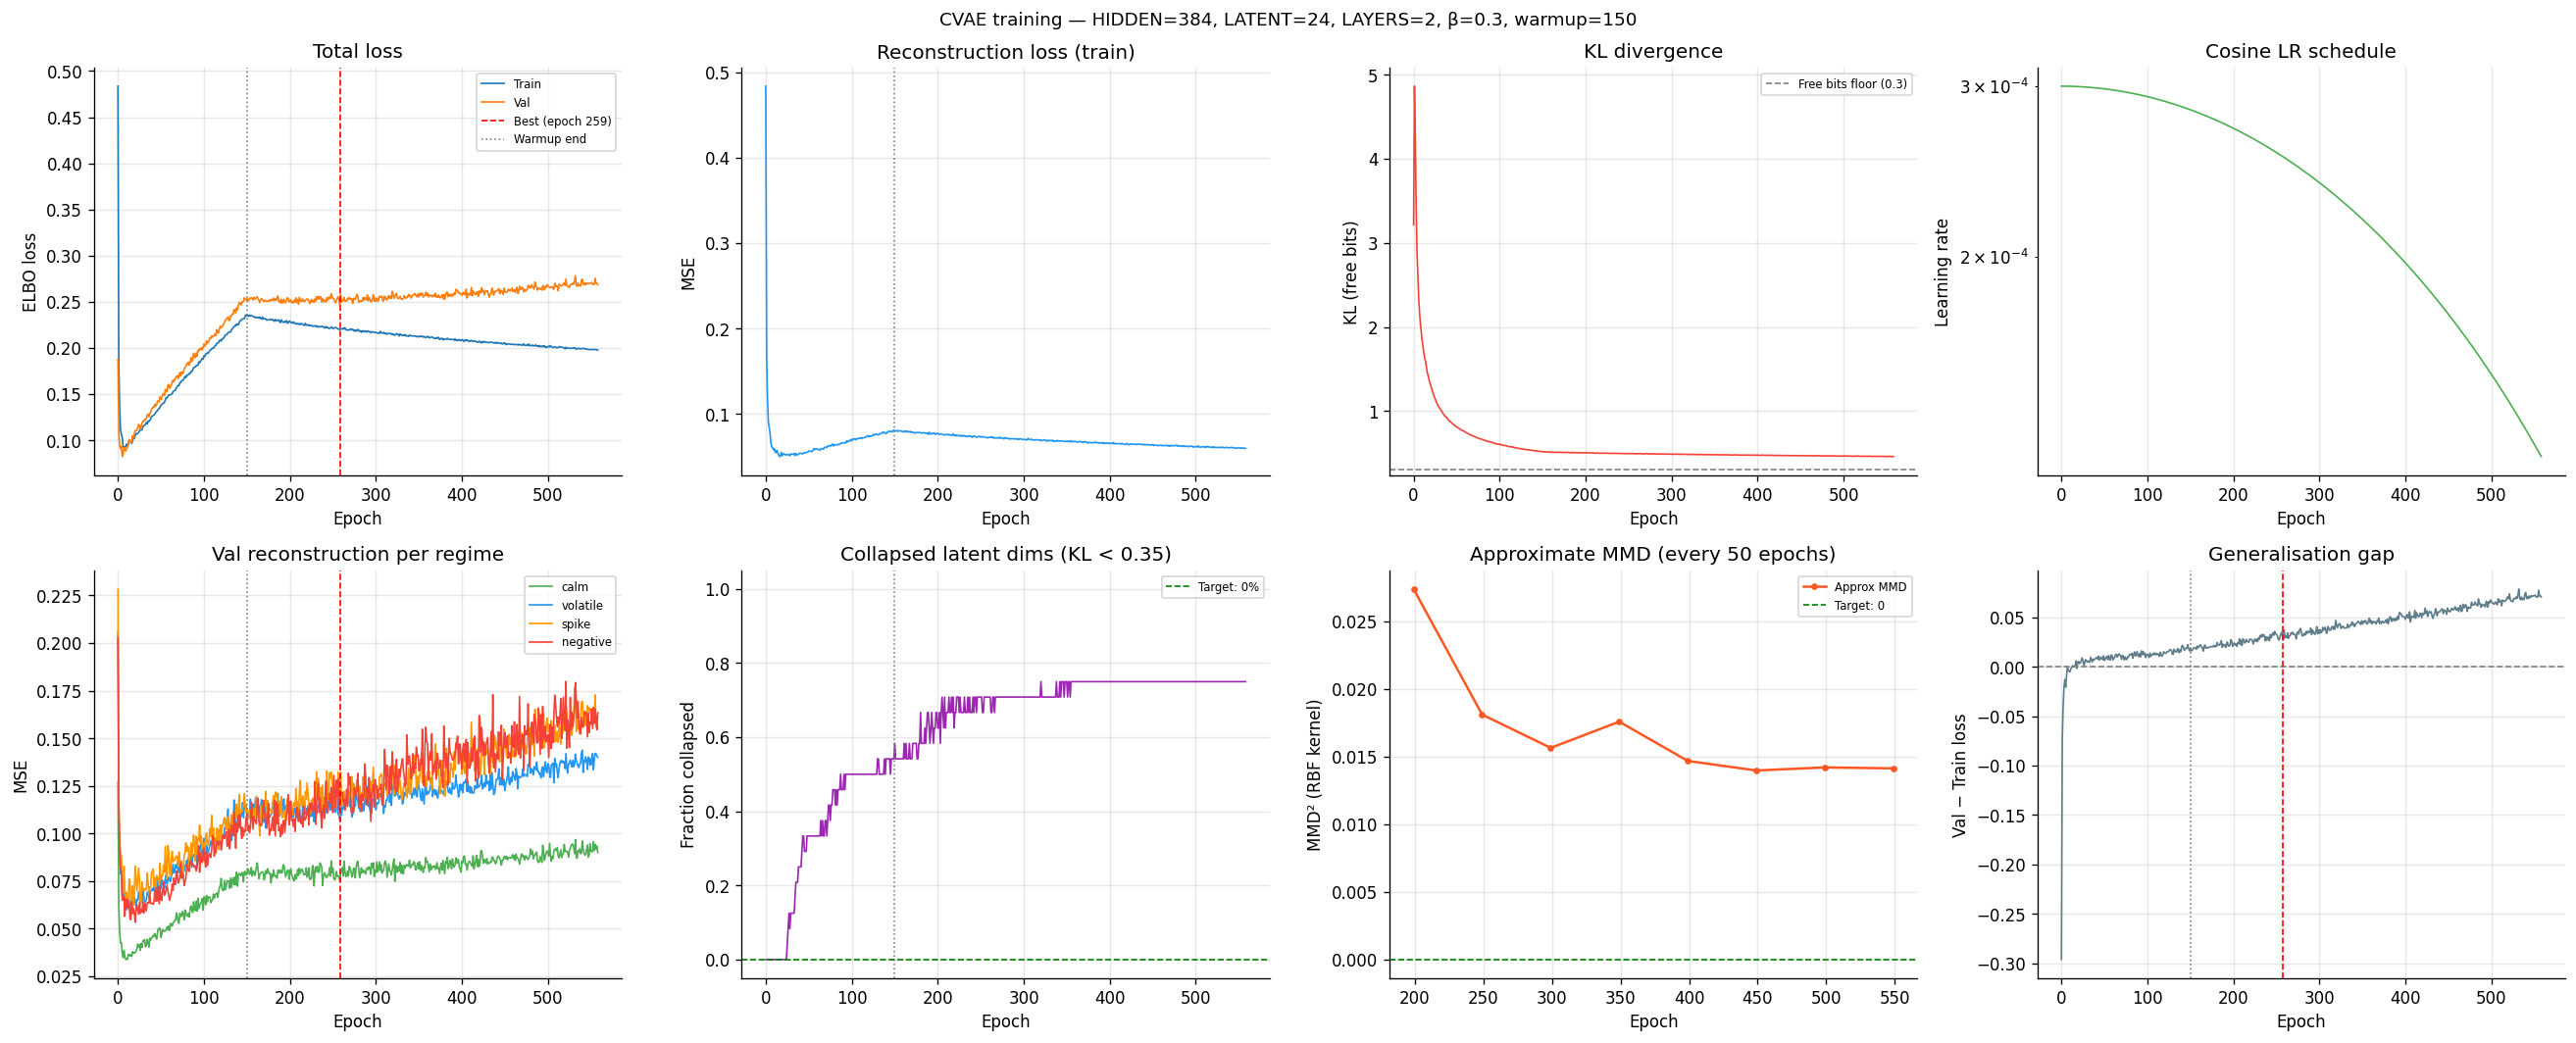

In [36]:
# ── Plot training curves ───────────────────────────────────────────────────────
REGIME_COLORS = {
    "calm":     "#4CAF50",
    "volatile": "#2196F3",
    "spike":    "#FF9800",
    "negative": "#F44336",
}

fig, axes = plt.subplots(2, 4, figsize=(22, 9))
fig.suptitle(
    f"CVAE training — HIDDEN={HIDDEN_DIM}, LATENT={LATENT_DIM}, "
    f"LAYERS={N_LAYERS}, β={BETA_MAX}, warmup={BETA_WARMUP}",
    fontsize=11
)

# ── Row 1: existing panels ────────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(train_losses, label="Train", lw=1)
ax.plot(val_losses,   label="Val",   lw=1)
ax.axvline(best_epoch, color="red", ls="--", lw=1,
           label=f"Best (epoch {best_epoch+1})")
ax.axvline(BETA_WARMUP, color="grey", ls=":", lw=1, label="Warmup end")
ax.set_xlabel("Epoch"); ax.set_ylabel("ELBO loss")
ax.set_title("Total loss"); ax.legend(fontsize=7)

ax = axes[0, 1]
ax.plot(recon_losses, color="#2196F3", lw=1)
ax.axvline(BETA_WARMUP, color="grey", ls=":", lw=1)
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE")
ax.set_title("Reconstruction loss (train)")

ax = axes[0, 2]
ax.plot(kl_losses, color="#F44336", lw=1)
ax.axhline(min_kl, color="grey", ls="--", lw=1, label=f"Free bits floor ({min_kl})")
ax.set_xlabel("Epoch"); ax.set_ylabel("KL (free bits)")
ax.set_title("KL divergence"); ax.legend(fontsize=7)

ax = axes[0, 3]
ax.plot(lr_history, color="#4CAF50", lw=1)
ax.set_xlabel("Epoch"); ax.set_ylabel("Learning rate")
ax.set_title("Cosine LR schedule"); ax.set_yscale("log")

# ── Row 2: new diagnostic panels ─────────────────────────────────────────────
ax = axes[1, 0]
for regime_name, color in REGIME_COLORS.items():
    vals = regime_recon_history[regime_name]
    if vals:
        ax.plot(vals, label=regime_name, color=color, lw=1)
ax.axvline(BETA_WARMUP, color="grey", ls=":", lw=1)
ax.axvline(best_epoch,  color="red",  ls="--", lw=1)
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE")
ax.set_title("Val reconstruction per regime")
ax.legend(fontsize=7)

ax = axes[1, 1]
ax.plot(collapsed_dims_history, color="#9C27B0", lw=1)
ax.axvline(BETA_WARMUP, color="grey", ls=":", lw=1)
ax.axhline(0.0, color="green", ls="--", lw=1, label="Target: 0%")
ax.set_xlabel("Epoch"); ax.set_ylabel("Fraction collapsed")
ax.set_title(f"Collapsed latent dims (KL < {min_kl+0.05:.2f})")
ax.set_ylim(-0.05, 1.05); ax.legend(fontsize=7)

ax = axes[1, 2]
if mmd_history:
    mmd_epochs, mmd_vals = zip(*mmd_history)
    ax.plot(mmd_epochs, mmd_vals, color="#FF5722", lw=1.5, marker="o",
            markersize=3, label="Approx MMD")
    ax.axhline(0.0, color="green", ls="--", lw=1, label="Target: 0")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MMD² (RBF kernel)")
    ax.set_title("Approximate MMD (every 50 epochs)")
    ax.legend(fontsize=7)
else:
    ax.text(0.5, 0.5, "No MMD data yet\n(computed post-warmup)",
            ha="center", va="center", transform=ax.transAxes)
    ax.set_title("Approximate MMD")

ax = axes[1, 3]
# Train/val gap — growing gap = overfitting, shrinking = underfitting
gap = [v - t for t, v in zip(train_losses, val_losses)]
ax.plot(gap, color="#607D8B", lw=1)
ax.axhline(0.0, color="grey", ls="--", lw=1)
ax.axvline(BETA_WARMUP, color="grey", ls=":", lw=1)
ax.axvline(best_epoch,  color="red",  ls="--", lw=1)
ax.set_xlabel("Epoch"); ax.set_ylabel("Val − Train loss")
ax.set_title("Generalisation gap")

plt.tight_layout()
plt.savefig(DATA_DIR / "04a_training_curves.png", bbox_inches="tight", dpi=120)
plt.show()

---
## 4. Generation

We generate synthetic log-signatures by:
1. Sampling a conditioning vector $c$ from the empirical distribution
   (or constructing a specific scenario)
2. Sampling $z \sim \mathcal{N}(0, I)$
3. Decoding: $\hat{x} = f_\theta(z, c)$
4. Unnormalising with the scaler fitted on training data

For sequential generation we chain segments: the generated log-signature
at step $t$ becomes part of the conditioning vector at step $t+1$.


In [16]:
# ── Generate 10,000 synthetic log-signatures ──────────────────────────────────
model.load_state_dict(torch.load(DATA_DIR / "cvae_model.pt"))
model.eval()
model.eval()
N_GENERATE = 10_000

# Temperature scaling: multiply latent noise by T_GEN > 1 to widen
# the generated distribution toward the real std (ratio target: 1/0.59 ≈ 1.69).
# This is a post-hoc calibration — does not change model weights.


np.random.seed(42)
# Target regime fractions: match real distribution but boost spike/negative
TARGET_FRACTIONS = {"calm": 0.30, "volatile": 0.30, "spike": 0.25, "negative": 0.15}

# Build regime-stratified index pool
# Use full dataset as generation pool (all 6,570 segments, not just training split)
# C is the full conditioning matrix pre-split; df["regime"] is the matching regime list
all_regimes_full = df["regime"].to_list()

regime_indices = {r: [] for r in TARGET_FRACTIONS}
for i, r in enumerate(all_regimes_full):
    if r in regime_indices:
        regime_indices[r].append(i)

print("Pool sizes:", {r: len(v) for r, v in regime_indices.items()})

idx = []
for regime_name, frac in TARGET_FRACTIONS.items():
    n_regime = int(N_GENERATE * frac)
    pool     = regime_indices[regime_name]
    idx.extend(np.random.choice(pool, size=n_regime, replace=True).tolist())

idx = np.array(idx)
np.random.shuffle(idx)
C_all = np.vstack([C_train, C_val])
C_gen = torch.tensor(C_all[idx]).to(device)

GEN_BATCH = 512
generated_logsigs = []

T_GEN_BY_REGIME = {0: 1.3, 1: 1.3, 2: 1.8, 3: 1.8}

with torch.no_grad():
    for i in range(0, N_GENERATE, GEN_BATCH):
        c_batch     = C_gen[i:i+GEN_BATCH]
        regime_oh   = c_batch[:, C_SCALAR_DIMS:C_SCALAR_DIMS+C_REGIME_DIMS].cpu().numpy()
        regime_ids  = regime_oh.argmax(axis=1)
        temps       = torch.tensor(
            [T_GEN_BY_REGIME[r] for r in regime_ids], dtype=torch.float32
        ).to(device).unsqueeze(1)
        z     = torch.randn(len(c_batch), LATENT_DIM).to(device) * temps
        x_hat = model.decoder(z, c_batch)
        generated_logsigs.append(x_hat.cpu().numpy())

generated_logsigs = np.concatenate(generated_logsigs, axis=0)
generated_logsigs_unnorm = scaler_X.inverse_transform(generated_logsigs)

print(f"Generated {len(generated_logsigs):,} log-signatures (T_GEN by regime: {T_GEN_BY_REGIME})")
print(f"Shape: {generated_logsigs_unnorm.shape}")


Pool sizes: {'calm': 2045, 'volatile': 2004, 'spike': 1846, 'negative': 675}
Generated 10,000 log-signatures (T_GEN by regime: {0: 1.3, 1: 1.3, 2: 1.8, 3: 1.8})
Shape: (10000, 31)


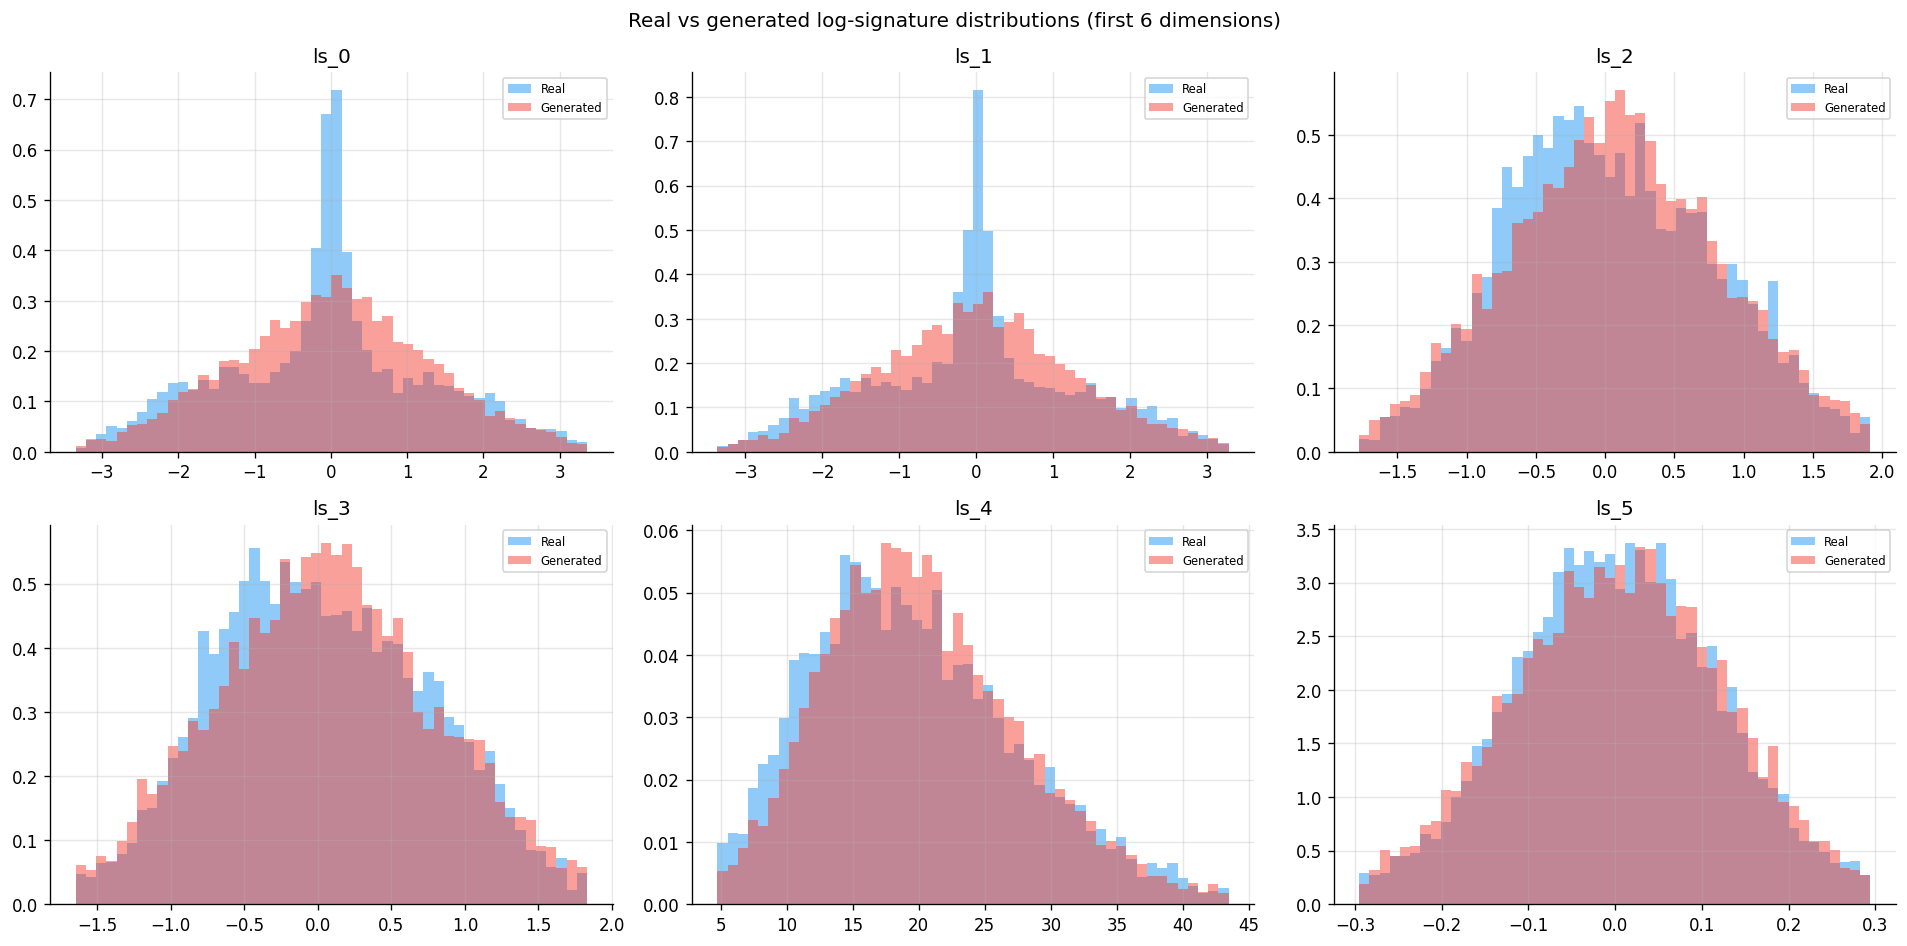

In [17]:
# ── Quick quality check: compare real vs generated distributions ───────────────
real_logsigs = scaler_X.inverse_transform(X_scaled)

# Check first 6 log-signature dimensions
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Real vs generated log-signature distributions (first 6 dimensions)",
             fontsize=12)

for i, ax in enumerate(axes.flat):
    real_vals = real_logsigs[:, i]
    gen_vals  = generated_logsigs_unnorm[:, i]

    # Common range
    lo = np.percentile(real_vals, 1)
    hi = np.percentile(real_vals, 99)

    ax.hist(real_vals, bins=50, density=True, alpha=0.5,
            color="#2196F3", label="Real", range=(lo, hi))
    ax.hist(gen_vals,  bins=50, density=True, alpha=0.5,
            color="#F44336", label="Generated", range=(lo, hi))
    ax.set_title(f"ls_{i}")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(DATA_DIR / "04a_logsig_distributions.png", bbox_inches="tight")
plt.show()

Generated 5 year-long chains
Each chain: 52 segments x 31 log-sig dims


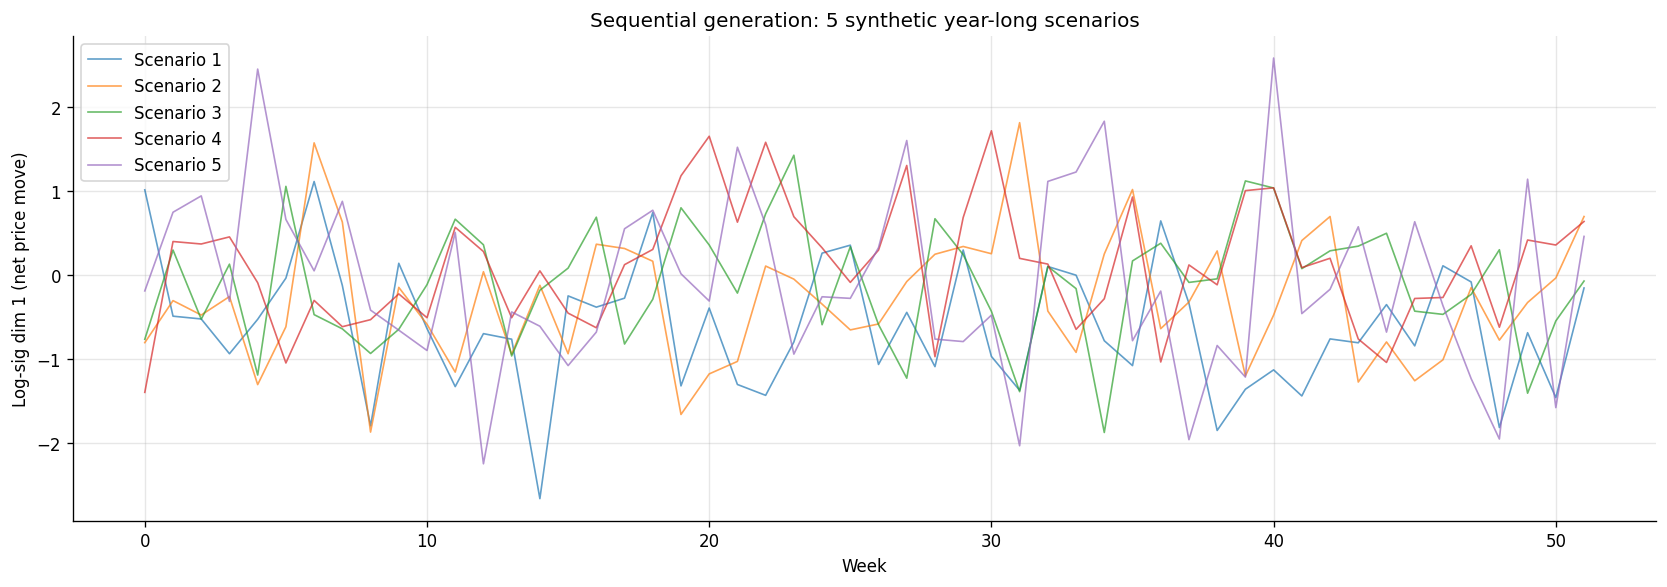

In [18]:
# ── Sequential generation: chain 52 weekly segments → 1 year ─────────────────
N_STEPS  = 52
N_CHAINS = 5

model.eval()
chains = []

for chain_idx in range(N_CHAINS):
    chain_logsigs = []

    start_idx = np.random.randint(0, len(C_train))

    # Use named constants from cell 7 to index C correctly
    # C layout: [scalars(C_SCALAR_DIMS) | regime(C_REGIME_DIMS) | PCA(N_LAGGED_PCS)]
    c_scalar = torch.tensor(
        C_train[start_idx:start_idx+1, :C_SCALAR_DIMS]
    ).to(device)
    c_regime = torch.tensor(
        C_train[start_idx:start_idx+1, C_SCALAR_DIMS:C_SCALAR_DIMS+C_REGIME_DIMS]
    ).to(device)

    prev_pca = torch.zeros(1, N_LAGGED_PCS).to(device)

    with torch.no_grad():
        for step in range(N_STEPS):
            # Build full conditioning: [scalars | regime | lagged_PCA]
            c = torch.cat([c_scalar, c_regime, prev_pca], dim=1)
            assert c.shape[1] == cond_dim, f"cond dim mismatch: {c.shape[1]} != {cond_dim}"

            z     = torch.randn(1, LATENT_DIM).to(device) * T_GEN_BY_REGIME[int(c_regime.argmax().item())]
            x_hat = model.decoder(z, c)
            chain_logsigs.append(x_hat.cpu().numpy()[0])

            x_hat_np     = scaler_X.inverse_transform(x_hat.cpu().numpy())
            x_hat_scaled = scaler_X.transform(x_hat_np).astype(np.float32)
            prev_pca     = torch.tensor(pca_lagged.transform(x_hat_scaled)).to(device)

    chains.append(np.stack(chain_logsigs))

print(f"Generated {N_CHAINS} year-long chains")
print(f"Each chain: {N_STEPS} segments x {logsig_dim} log-sig dims")

fig, ax = plt.subplots(figsize=(14, 5))
for i, chain in enumerate(chains):
    ax.plot(chain[:, 1], lw=1, alpha=0.7, label=f"Scenario {i+1}")
ax.set_xlabel("Week")
ax.set_ylabel("Log-sig dim 1 (net price move)")
ax.set_title("Sequential generation: 5 synthetic year-long scenarios")
ax.legend()
plt.tight_layout()
plt.savefig(DATA_DIR / "04a_sequential_generation.png", bbox_inches="tight")
plt.show()


In [19]:
print(f"N_LAGGED_PCS: {N_LAGGED_PCS}")
print(f"C_train shape: {C_train.shape}")
print(f"Model cond_dim: {model.encoder.input_proj[0].in_features - logsig_dim}")

N_LAGGED_PCS: 30
C_train shape: (5256, 38)
Model cond_dim: 38


---
## 5. Save outputs


In [22]:
# ── Save generated log-signatures and model parameters ────────────────────────
cond_regimes = [df["regime"].to_list()[i] for i in idx]

# Recover scalar conditioning values in original units
# C_gen[:, :C_SCALAR_DIMS] = [realised_vol, mean_price, total_wind_mw, net_imbalance_volume]
C_gen_scalars_unnorm = scaler_C.inverse_transform(
    C_gen[:, :C_SCALAR_DIMS].cpu().numpy()
)
SCALAR_COND_NAMES = ["realised_vol", "mean_price", "total_wind_mw", "net_imbalance_volume"]

gen_records = {
    "sample_id": list(range(N_GENERATE)),
    "regime":    cond_regimes,
}
for j, col_name in enumerate(SCALAR_COND_NAMES):
    gen_records[col_name] = C_gen_scalars_unnorm[:, j].tolist()
for j, col_name in enumerate(ls_cols_active):
    gen_records[col_name] = generated_logsigs_unnorm[:, j].tolist()

df_gen = pl.DataFrame(gen_records)
out_path = DATA_DIR / "cvae_generated_logsigs.parquet"
df_gen.write_parquet(out_path)
print(f"Saved: cvae_generated_logsigs.parquet "
      f"({out_path.stat().st_size/1e6:.2f} MB)")

# Save all parameters needed for inference in downstream notebooks
scaler_params = {
    "X_mean":            scaler_X.mean_.tolist(),
    "X_scale":           scaler_X.scale_.tolist(),
    "C_mean":            scaler_C.mean_.tolist(),
    "C_scale":           scaler_C.scale_.tolist(),
    "pca_lagged_mean":   pca_lagged.mean_.tolist(),
    "pca_lagged_components": pca_lagged.components_.tolist(),
    "regime_map":         REGIME_MAP,
    "c_scalar_dims":      C_SCALAR_DIMS,
    "c_regime_dims":      C_REGIME_DIMS,
    "t_gen_by_regime":    T_GEN_BY_REGIME,
    "latent_dim":        LATENT_DIM,
    "hidden_dim":        HIDDEN_DIM,
    "n_layers":          N_LAYERS,
    "cond_dim":          cond_dim,
    "logsig_dim":        logsig_dim,
    "n_lagged_pcs":      N_LAGGED_PCS,
    "best_epoch":        259, #note to save rerunning the training loop I just put these last two in from the last best run
    "best_val_loss":     0.2701,
}
with open(DATA_DIR / "cvae_params.json", "w") as f:
    json.dump(scaler_params, f, indent=2)
print("Saved: cvae_params.json")

print("\nAll files in data directory:")
for fp in sorted(DATA_DIR.glob("*")):
    if fp.suffix in [".parquet", ".json", ".pt", ".png"]:
        print(f"  {fp.name}: {fp.stat().st_size/1e3:.1f} KB")

Saved: cvae_generated_logsigs.parquet (1.52 MB)
Saved: cvae_params.json

All files in data directory:
  01_raw_data_overview.png: 320.4 KB
  02a_return_distribution.png: 89.8 KB
  02b_seasonality.png: 87.3 KB
  02c_autocorrelation.png: 84.9 KB
  02d_spikes.png: 103.4 KB
  02e_wind_price.png: 139.7 KB
  02f_regimes.png: 149.4 KB
  03a_path_construction.png: 63.7 KB
  03b_signature_pca.png: 244.7 KB
  03c_levy_area.png: 98.4 KB
  04a_logsig_distributions.png: 88.2 KB
  04a_sequential_generation.png: 237.2 KB
  04a_training_curves.png: 305.2 KB
  05a_ks_test.png: 66.2 KB
  05b_mmd_test.png: 49.5 KB
  05c_stylized_facts.png: 286.2 KB
  carbon_intensity.parquet: 4415.7 KB
  cvae_4D_d4_best.pt: 5105.6 KB
  cvae_generated_logsigs.parquet: 1518.8 KB
  cvae_model.pt: 5105.3 KB
  cvae_params.json: 29.2 KB
  elexon_generation.parquet: 7061.1 KB
  elexon_system_prices.parquet: 12483.7 KB
  logsigs.parquet: 1753.6 KB
  master.parquet: 21327.3 KB
  norm_stats.json: 0.7 KB
  optuna_results.json: 4.1 

---
## Summary

| Component | Detail |
|-----------|--------|
| Architecture | CVAE with 2-layer encoder + decoder, LeakyReLU, dropout |
| Latent dim | 32 |
| Conditioning | Realised vol, wind, seasonality, regime, lagged log-sig |
| Training | 200 epochs, Adam, β-annealing, LR scheduling |
| Input | Log-signatures of 5-day price segments |
| Output | 10,000 synthetic log-signatures + 5 year-long scenarios |

**What to check in the distribution plots**: the red (generated) and blue (real)
histograms should broadly overlap for all 6 dimensions shown. If the generated
distribution is narrower it means the KL term is too dominant — reduce beta.
If the shapes diverge significantly, try more epochs or increase hidden_dim to 512.

**Next**: `05_validation.ipynb` — apply the signature MMD two-sample test to
rigorously compare the distribution of real vs generated paths on path space,
and check all stylized facts from notebook 02 against the generated data.
